In [1]:
# Colab Setup (Run this first)

In [2]:
!pip install litebird_sim rich


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


To run this notebook, you have several options:

-   If you are running this under Binder, you should already be set!
-   If you are running this under Google Colab, be sure to run the cell with `!pip install…` that is right above the title.
-   If you are running this locally, you should first create and activate a new virtual environment with the commands

    ```
    python -m venv ./my_venv
    source ./my_venv/bin/activate
    ```

    (you can use Conda environments, if you prefer) and install Jupyter and litebird_sim in it:

    ```
    pip install jupyter litebird_sim
    ```

    If you have a local copy of the `litebird_sim` repository cloned from <https://github.com/litebird/litebird_sim> (e.g., because you're part of the Simulation Team!), you can use a _development install_ instead:

    ```
    cd /my/local/copy/litebird_sim
    pip install -e .
    ```


## Import Modules

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import healpy as hp
import litebird_sim as lbs

## Define Parameters

In [4]:
start_time = 0
time_span_s = 2 * 24 * 3600
nside = 64
hwp_radpsec = lbs.IdealHWP(
    46 * 2 * np.pi / 60,
).ang_speed_radpsec

imo_location = "schema.json"
imo = lbs.Imo(flatfile_location=imo_location)
imo_version = "IMo_vPostKDP2_Option2"

## Create Simulation

In [5]:
sim = lbs.Simulation(
    start_time=start_time, duration_s=time_span_s, random_seed=0, imo=imo
)

comm = sim.mpi_comm

## Define Frequency Channel

In [6]:
channel = "M1_L"

channelinfo = lbs.FreqChannelInfo.from_imo(
    url=f"/releases/{imo_version}/LMHFT/{channel}/channel_info",
    imo=imo,
)

## Define Scanning Strategy

In [7]:
sim.set_scanning_strategy(
    imo_url=f"/releases/{imo_version}/Observation/Scanning_Strategy"
)

## Define Instrument

In [8]:
instrument_info = lbs.InstrumentInfo.from_imo(
        imo,
        f"/releases/{imo_version}/LMHFT/instrument_info",
    )

sim.set_instrument(instrument_info)

hwp_radpsec = instrument_info.hwp_rpm * 2 * np.pi / 60

## Set HWP

In [9]:
# if Mueller formalism
#
#sim.set_hwp(
#    lbs.NonIdealHWP(hwp_radpsec, harmonic_expansion=True, calculus=lbs.Calc.MUELLER)
#)

# if Jones formalism
sim.set_hwp(
    lbs.NonIdealHWP(hwp_radpsec, harmonic_expansion=True, calculus=lbs.Calc.JONES)
)


## Define Detectors

In [10]:
det = lbs.DetectorInfo.from_imo(
    url=f"/releases/{imo_version}/LMHFT/{channel}/{channelinfo.detector_names[0]}/detector_info",
    imo=imo,
)

# if Mueller
#
#det.mueller_hwp = {
#    "0f": np.array([[1, 0, 0], [0, 0, 0], [0, 0, 0]], dtype=np.float64),
#    "2f": np.array([[0, 0, 0], [0, 0, 0], [0, 0, 0]], dtype=np.float64),
#    "4f": np.array(
#        [
#            [0, 0, 0],
#            [3.5e-5, 1, 1],
#            [1e-4, 1, 1],
#        ],
#        dtype=np.float64,
#    ),
#}

# if Jones 	
#
det.jones_hwp = {
    "0f": np.array([[9.67E-01 * np.exp(1j*np.deg2rad(5.51E+01)), 6.16E-02 * np.exp(1j*np.deg2rad(1.26E+02))], [6.18E-02	* np.exp(1j*np.deg2rad(1.25E+02)), 9.85E-01 * np.exp(1j*np.deg2rad(-1.46E+02))]], dtype=np.complex128),
    "2f": np.array([[0, 0], [0, 0]], dtype=np.complex128),
}

[2026-02-24 16:51:29,071 WARNING MPI#0000] Detector '005_000_XX_094_000': mueller_hwp is not a 4x4 numpy array (found type <class 'dict'>, shape None)


## Create Observations and Prepare Pointings

In [11]:
(obs,) = sim.create_observations(
    detectors=[det],
)

sim.prepare_pointings(append_to_report=False)

## Generate Input Sky Maps

In [12]:
sky_params = lbs.SkyGenerationParams(
    make_cmb=True,
    make_dipole=True,
    make_fg=True,
    fg_models=["s0", "f1", "d0"],
    seed_cmb=1,  # set this seed if you want to fix the CMB realization
    apply_beam=True,  # if True, smooths the input map by the beam of the channel
    bandpass_integration=False,  # if True, integrates over the top-hat bandpass of the channel
    units="K_CMB",
    output_type="map",
    nside=nside,
)

sky = sim.get_sky(
    parameters=sky_params,
    channels=channelinfo,
)

[2026-02-24 16:51:29,210 INFO MPI#0000] Generating CMB...
[2026-02-24 16:51:29,233 INFO MPI#0000] Generating Foregrounds...
[2026-02-24 16:51:29,234 INFO MPI#0000] Retrieve data for pysm_2/synch_t_new.fits (if not cached already)
[2026-02-24 16:51:29,235 INFO MPI#0000] NSIDE = 512
[2026-02-24 16:51:29,235 INFO MPI#0000] ORDERING = RING in fits file
[2026-02-24 16:51:29,235 INFO MPI#0000] INDXSCHM = IMPLICIT
[2026-02-24 16:51:29,268 INFO MPI#0000] Retrieve data for pysm_2/synch_q_new.fits (if not cached already)
[2026-02-24 16:51:29,269 INFO MPI#0000] NSIDE = 512
[2026-02-24 16:51:29,269 INFO MPI#0000] ORDERING = RING in fits file
[2026-02-24 16:51:29,270 INFO MPI#0000] INDXSCHM = IMPLICIT
[2026-02-24 16:51:29,296 INFO MPI#0000] Retrieve data for pysm_2/synch_u_new.fits (if not cached already)
[2026-02-24 16:51:29,297 INFO MPI#0000] NSIDE = 512
[2026-02-24 16:51:29,297 INFO MPI#0000] ORDERING = RING in fits file
[2026-02-24 16:51:29,298 INFO MPI#0000] INDXSCHM = IMPLICIT
[2026-02-24 16:

## Generate HwpSys object and Set its parameters

## Fill TOD and perform Mapmaking on-the-fly

In [13]:
lbs.scan_map_in_observations(
    observations=[obs],
    maps=sky,
)

In [14]:
output_map = sim.make_brahmap_gls_map(
                nside=64,
            ).GLS_maps


-------------------------- ProcessTimeSamples Summary --------------------------
Processed 12960000 time samples for npix=49152
Found 25980 pathological pixels on the map
Map-maker will take into account only 23172 pixels
--------------------------------------------------------------------------------


## Show Output Maps

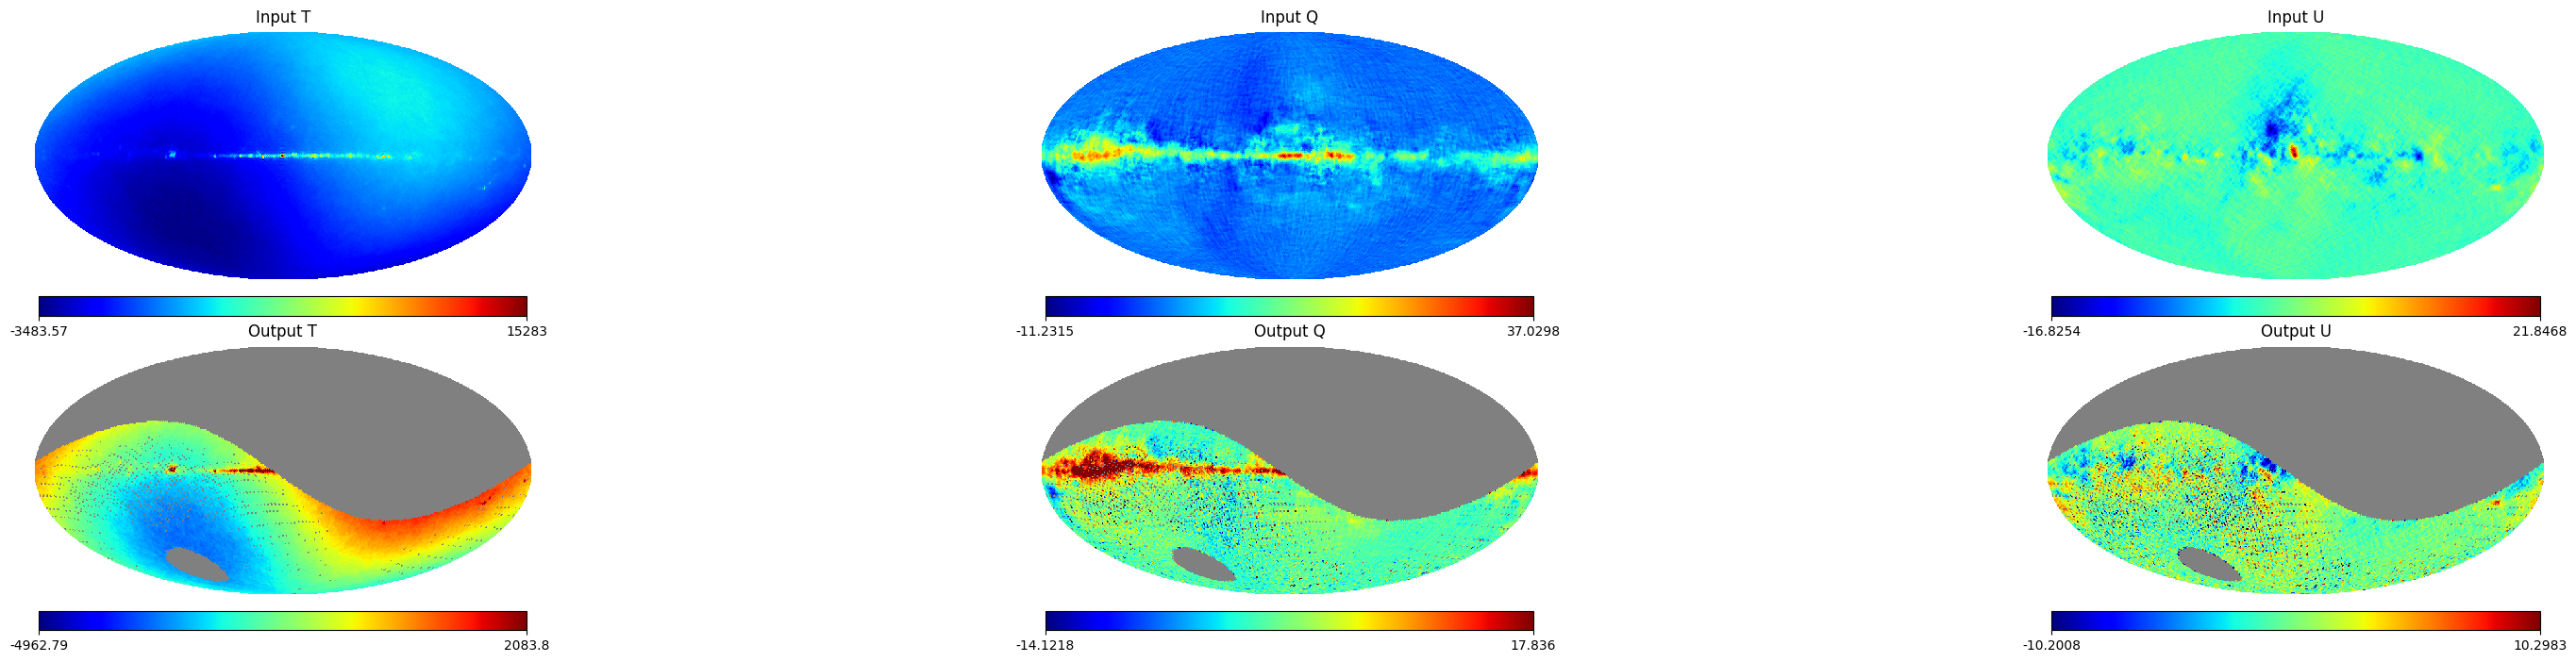

In [15]:
plt.figure(figsize=(32, 10))
stokes_parameters = ["T", "Q", "U"]
output_normalized=1e6*output_map
for i in range(3):
    hp.mollview(
        sky['M1_L'].values[i]* 1e6,
        cmap="jet",
        sub=(3, 3, i + 1),
        title="Input " + stokes_parameters[i],
    )
    hp.mollview(
        output_map[i]* 1e6,
        cmap="jet",
        min=np.mean(output_normalized[i])-3*np.std(output_normalized[i]),
        max=np.mean(output_normalized[i])+3*np.std(output_normalized[i]),
        sub=(3, 3, i + 4),
        title="Output " + stokes_parameters[i],
    )